In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import PowerTransformer


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_std = pt.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.735252,0.067055,0.176922,0.072022,0.104910,-0.000955,-0.190635,-0.021816,0.103330,-0.274204,...,1.042615,-0.340702,-0.305657,0.622355,-0.784694,-0.404309,-0.370546,-0.074611,-0.654022,-0.325914
1,1.029207,-1.298903,-2.046814,-1.421627,-1.344285,-1.500591,-0.993359,-1.453969,-1.512997,-0.807533,...,1.929439,1.907148,0.939011,-1.489676,-0.784694,1.826912,1.188847,1.689445,1.560347,0.852496
2,0.480839,0.581443,0.777497,0.444135,0.593101,0.323069,0.452558,0.617141,0.651680,0.764603,...,-0.799521,0.082511,0.147926,0.741227,0.236612,-0.110511,-1.026597,-1.065926,-0.824361,-0.125568
3,1.080021,-0.986786,-1.714238,-1.314128,-1.459229,-1.636023,-0.469852,-1.044798,-1.371728,-0.684399,...,1.846691,1.751709,0.986180,-1.383365,-0.784694,0.301039,1.216712,-1.065926,1.122247,1.296177
4,0.946400,-0.689355,-0.765790,-0.468644,-0.828545,-0.393167,-0.250949,-0.482649,-0.997043,0.080384,...,-0.799521,0.230152,0.900131,-1.607406,1.784568,1.860059,1.405024,1.782787,1.919501,1.900963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.200607,-0.027337,-0.469576,-0.601731,-0.503317,-0.423114,-0.843152,-0.642530,-0.522668,-0.587170,...,-0.799521,-0.050750,-0.332827,0.301629,-0.784694,-0.811377,0.115613,-1.065926,-0.733951,-0.371465
135,0.368838,1.721586,0.901503,0.002519,0.280704,0.389333,0.314470,0.253816,0.527224,0.286038,...,-0.000653,0.215135,0.445866,-0.027763,-0.784694,0.654869,-0.266178,0.138716,-0.145951,0.659834
136,0.459982,0.996190,0.306773,-0.316986,-0.665131,-0.117023,0.464099,-0.299082,0.050381,0.019889,...,-0.799521,-1.105445,-1.073694,1.149438,-0.784694,-1.222412,-0.358889,-1.065926,-0.928256,0.305804
137,-0.551976,-0.284014,0.183709,0.314722,0.178739,0.095604,0.005239,0.207510,0.224901,0.081128,...,-0.799521,-0.455330,0.120914,-0.137599,-0.784694,0.225798,0.256551,-0.175482,-0.103535,0.868321


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

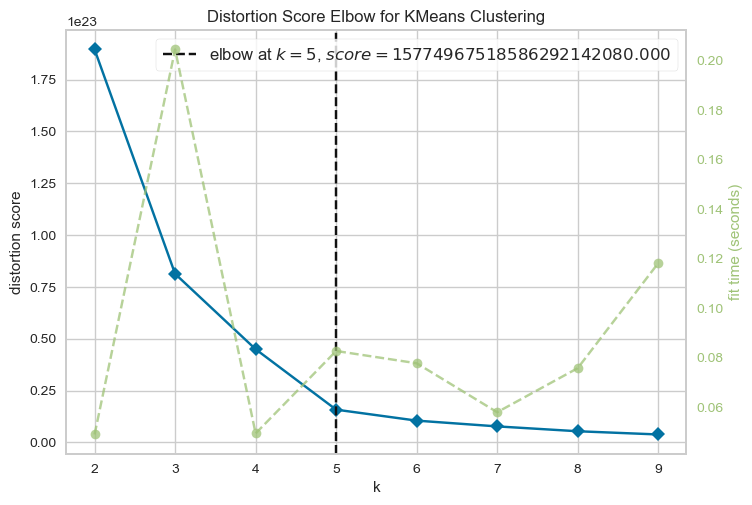

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glcm_DifferenceAverage_d_1_PET_c04
Correlation coefficient: 1.0072463768115951


1
Most correlated column: LBP_102_PET
Correlation coefficient: 1.0072463768115956


2
Most correlated column: glszm_GrayLevelNonUniformity_PET_c04
Correlation coefficient: 1.0072463768115951


3
Most correlated column: first_order_RobustMeanAbsoluteDeviation_PET
Correlation coefficient: 1.0072463768115951


4
Most correlated column: glrlm_RunLengthNonUniformityNormalized_CT_b20
Correlation coefficient: 1.007246376811595




In [22]:
selected_features

['glcm_DifferenceAverage_d_1_PET_c04',
 'LBP_102_PET',
 'glszm_GrayLevelNonUniformity_PET_c04',
 'first_order_RobustMeanAbsoluteDeviation_PET',
 'glrlm_RunLengthNonUniformityNormalized_CT_b20']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Yeo-Johnson Transformation

In [24]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [25]:
X_new

,glcm_DifferenceAverage_d_1_PET_c04,LBP_102_PET,glszm_GrayLevelNonUniformity_PET_c04,first_order_RobustMeanAbsoluteDeviation_PET,glrlm_RunLengthNonUniformityNormalized_CT_b20
0,0.356587,0.000000,1.545455,2.608982,0.572390
1,0.420129,0.000000,2.166667,0.978390,0.551239
2,0.325835,0.000034,6.777778,1.184765,0.504802
3,0.401664,0.000000,2.090909,0.421149,0.667469
4,0.510112,0.000199,4.333333,0.914508,0.675873
...,...,...,...,...,...
134,0.409956,0.000000,4.000000,1.571160,0.482848
135,0.321183,0.000000,4.000000,0.941343,0.377902
136,0.374487,0.000000,2.428571,2.262096,0.446948
137,0.402135,0.000000,6.333333,1.167062,0.343403


In [26]:
X_new_std

,glcm_DifferenceAverage_d_1_PET_c04,LBP_102_PET,glszm_GrayLevelNonUniformity_PET_c04,first_order_RobustMeanAbsoluteDeviation_PET,glrlm_RunLengthNonUniformityNormalized_CT_b20
0,-0.094031,-0.784694,-1.814187,0.929474,1.138066
1,0.595643,-0.784694,-1.216065,-0.726455,0.960267
2,-0.468257,0.236612,0.613776,-0.444272,0.542538
3,0.405940,-0.784694,-1.278916,-1.693580,1.853525
4,1.412495,1.784568,-0.046796,-0.820591,1.910822
...,...,...,...,...,...
134,0.492151,-0.784694,-0.174107,0.011153,0.330872
135,-0.527421,-0.784694,-0.174107,-0.780622,-0.828713
136,0.111075,-0.784694,-1.015564,0.659936,-0.036790
137,0.410886,-0.784694,0.519526,-0.467274,-1.272208


In [27]:
MAASTRO_new

,glcm_DifferenceAverage_d_1_PET_c04,LBP_102_PET,glszm_GrayLevelNonUniformity_PET_c04,first_order_RobustMeanAbsoluteDeviation_PET,glrlm_RunLengthNonUniformityNormalized_CT_b20
0,0.335443,0.000026,7.437500,2.804536,0.351568
1,0.279434,0.000167,6.111111,1.112878,0.431179
2,0.310763,0.000057,2.750000,2.210455,0.378652
3,0.301684,0.000000,3.000000,1.225669,0.636279
4,0.300615,0.000000,8.428571,1.428017,0.342347
...,...,...,...,...,...
94,0.327473,0.000000,3.842105,7.089688,0.502355
95,0.310449,0.000000,1.727273,2.165934,0.553299
96,0.264803,0.000000,9.666667,1.052365,0.386943
97,0.305581,0.000000,5.352941,2.313589,0.552452


In [28]:
MAASTRO_new_std

,glcm_DifferenceAverage_d_1_PET_c04,LBP_102_PET,glszm_GrayLevelNonUniformity_PET_c04,first_order_RobustMeanAbsoluteDeviation_PET,glrlm_RunLengthNonUniformityNormalized_CT_b20
0,-0.348239,0.033184,0.739277,1.068840,-1.164091
1,-1.090997,1.682719,0.469013,-0.539020,-0.207337
2,-0.662484,0.693043,-0.799685,0.617054,-0.819450
3,-0.783134,-0.784694,-0.650645,-0.391916,1.632873
4,-0.797524,-0.784694,0.901693,-0.147962,-1.286349
...,...,...,...,...,...
94,-0.447593,-0.784694,-0.239100,2.961685,0.519418
95,-0.666615,-0.784694,-1.617427,0.579456,0.977914
96,-1.303381,-0.784694,1.070911,-0.621639,-0.718073
97,-0.731004,-0.784694,0.276497,0.701938,0.970661


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 13:50:37,108] A new study created in memory with name: no-name-74fb7ccc-643b-48b6-b2f5-1af568b8e938


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-15 13:50:37,431] A new study created in memory with name: no-name-511e4c6f-b1fa-4b5b-a35c-46ab16f429fe


Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6472868217054264
Fold 3 C-index: 0.5361702127659574
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:37,424] Trial 0 finished with value: 0.5402198379244764 and parameters: {}. Best is trial 0 with value: 0.5402198379244764.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5402198379244764], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 37, 192827), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 37, 423897), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5402198379244764


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.285697469649694
Fold 2 IBS: 0.2227840843281045
Fold 3 IBS: 0.23201458641727668
Fold 4 IBS: 0.2658480444490381
Fold 5 IBS: 0.2406491414957891
[I 2024-04-15 13:50:37,747] Trial 0 finished with value: 0.2493986652679805 and parameters: {}. Best is trial 0 with value: 0.2493986652679805.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2493986652679805], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 37, 473354), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 37, 747670), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2493986652679805


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.54
train_ibs:  0.249


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.532
IBS score: 0.24


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:37,979] A new study created in memory with name: no-name-9c915269-1dd0-4aa5-b9e9-e04259c8de1b


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4960159362549801


[I 2024-04-15 13:50:38,214] A new study created in memory with name: no-name-82edf3b7-e278-49e3-be84-bc78c6e93f0d


Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.48283261802575106
[I 2024-04-15 13:50:38,207] Trial 0 finished with value: 0.5785057981624967 and parameters: {}. Best is trial 0 with value: 0.5785057981624967.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5785057981624967], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 38, 17159), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 38, 207673), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5785057981624967


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710198922598
Fold 2 IBS: 0.2320398811913649
Fold 3 IBS: 0.2289818573366155
Fold 4 IBS: 0.24197476967541504
Fold 5 IBS: 0.22939559407385723
[I 2024-04-15 13:50:38,468] Trial 0 finished with value: 0.23592784085329574 and parameters: {}. Best is trial 0 with value: 0.23592784085329574.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784085329574], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 38, 263050), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 38, 468760), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784085329574


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.579
train_ibs:  0.236


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.509


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:38,620] A new study created in memory with name: no-name-cc19a401-0bd3-47f6-8dc7-5003310a84ab


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.5404255319148936
Fold 4 C-index: 0.532319391634981


[I 2024-04-15 13:50:39,087] A new study created in memory with name: no-name-3c14d0e0-e74c-48ed-9f27-ce08b9bfec94


Fold 5 C-index: 0.5107296137339056
[I 2024-04-15 13:50:39,065] Trial 0 finished with value: 0.5332210509448193 and parameters: {}. Best is trial 0 with value: 0.5332210509448193.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5332210509448193], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 38, 653589), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 39, 65401), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5332210509448193


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.28440868684180487
Fold 2 IBS: 0.2271289945215074
Fold 3 IBS: 0.2316366286934968
Fold 4 IBS: 0.26470744978358224
Fold 5 IBS: 0.24081687274237962
[I 2024-04-15 13:50:39,493] Trial 0 finished with value: 0.24973972651655418 and parameters: {}. Best is trial 0 with value: 0.24973972651655418.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24973972651655418], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 39, 118257), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 39, 493728), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24973972651655418


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.533
train_ibs:  0.25


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.531


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.24


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:39,870] A new study created in memory with name: no-name-82c6fa28-88b5-4d13-b461-37285b2e2233


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.5957446808510638
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:40,170] Trial 0 finished with value: 0.5451432498307657 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5451432498307657.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.6170212765957447
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:40,446] Trial 1 finished with value: 0.549398568979702 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.549398568979702.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.625531914893617
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:40,725] Trial 2 finished with value: 0.5503402403655121 and parameters: {'l1_ratio': 0.22692876841884668}. B

Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.6212765957446809
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:46,275] Trial 24 finished with value: 0.5494891765357248 and parameters: {'l1_ratio': 0.19621932764719313}. Best is trial 13 with value: 0.5942427355390524.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.48068669527896996
[I 2024-04-15 13:50:46,467] Trial 25 finished with value: 0.5820561462407972 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.5942427355390524.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.625531914893617
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:46,775] Trial 26 finished with value: 0.5503402403655121 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:52,505] Trial 48 finished with value: 0.5468453774903402 and parameters: {'l1_ratio': 0.5683872043393509}. Best is trial 13 with value: 0.5942427355390524.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.6127659574468085
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:52,789] Trial 49 finished with value: 0.5485475051499147 and parameters: {'l1_ratio': 0.4086630375960589}. Best is trial 13 with value: 0.5942427355390524.
Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.6085106382978723
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:50:53,146] Trial 50 finished with value: 0.5476964413201275 and parameters: {'l1_ratio': 0.472417665619005

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.28439702050858784
Fold 2 IBS: 0.22740387265295084
Fold 3 IBS: 0.22712071702028264
Fold 4 IBS: 0.2647728688865611
Fold 5 IBS: 0.2407893195722127
[I 2024-04-15 13:51:05,833] Trial 0 finished with value: 0.248896759728119 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.248896759728119.
Fold 1 IBS: 0.2842656764857384
Fold 2 IBS: 0.22840488950311602
Fold 3 IBS: 0.2263252537634573
Fold 4 IBS: 0.26490577159805573
Fold 5 IBS: 0.24072631968145877
[I 2024-04-15 13:51:06,228] Trial 1 finished with value: 0.24892558220636524 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.248896759728119.
Fold 1 IBS: 0.2842127046768092
Fold 2 IBS: 0.22873060314677865
Fold 3 IBS: 0.22615988832724107
Fold 4 IBS: 0.2649372116236268
Fold 5 IBS: 0.24069880958348627
[I 2024-04-15 13:51:06,520] Trial 2 finished with value: 0.24894784347158844 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.248896759728119.
Fold

Fold 4 IBS: 0.26497671925754934
Fold 5 IBS: 0.24067816779175333
[I 2024-04-15 13:51:14,643] Trial 25 finished with value: 0.2489791815487513 and parameters: {'l1_ratio': 0.1924891533890883}. Best is trial 10 with value: 0.23516432823331296.
Fold 1 IBS: 0.24878774935086145
Fold 2 IBS: 0.229820001084243
Fold 3 IBS: 0.22598604256032548
Fold 4 IBS: 0.24074223121666213
Fold 5 IBS: 0.23050710393105234
[I 2024-04-15 13:51:14,948] Trial 26 finished with value: 0.2351686256286289 and parameters: {'l1_ratio': 0.10668812734002123}. Best is trial 10 with value: 0.23516432823331296.
Fold 1 IBS: 0.2842215662813062
Fold 2 IBS: 0.22824459703454725
Fold 3 IBS: 0.22642377171638975
Fold 4 IBS: 0.2649313703925811
Fold 5 IBS: 0.24073585088886726
[I 2024-04-15 13:51:15,387] Trial 27 finished with value: 0.2489114312627383 and parameters: {'l1_ratio': 0.32271773281493693}. Best is trial 10 with value: 0.23516432823331296.
Fold 1 IBS: 0.2841004759476607
Fold 2 IBS: 0.22891033464425053
Fold 3 IBS: 0.2260887242

Fold 1 IBS: 0.2841610263897099
Fold 2 IBS: 0.2283508718763764
Fold 3 IBS: 0.22635722577642628
Fold 4 IBS: 0.26491422961090483
Fold 5 IBS: 0.24072961681521612
[I 2024-04-15 13:51:24,000] Trial 50 finished with value: 0.24890259409372675 and parameters: {'l1_ratio': 0.29786905280019904}. Best is trial 31 with value: 0.23516375063384953.
Fold 1 IBS: 0.24877520678654794
Fold 2 IBS: 0.22983256084634276
Fold 3 IBS: 0.22598818320890235
Fold 4 IBS: 0.2407462667992964
Fold 5 IBS: 0.23049750793676843
[I 2024-04-15 13:51:24,232] Trial 51 finished with value: 0.23516794511557157 and parameters: {'l1_ratio': 0.10569975297269}. Best is trial 31 with value: 0.23516375063384953.
Fold 1 IBS: 0.24795959322611313
Fold 2 IBS: 0.2308018115710385
Fold 3 IBS: 0.22654473096802985
Fold 4 IBS: 0.24115919889034895
Fold 5 IBS: 0.22989149640497308
[I 2024-04-15 13:51:24,481] Trial 52 finished with value: 0.23527136621210074 and parameters: {'l1_ratio': 0.046601842064264175}. Best is trial 31 with value: 0.23516375

Fold 1 IBS: 0.24830436085759972
Fold 2 IBS: 0.23035103576951516
Fold 3 IBS: 0.2261819022237472
Fold 4 IBS: 0.2409412810837617
Fold 5 IBS: 0.23014330837263153
[I 2024-04-15 13:51:33,977] Trial 76 finished with value: 0.23518437766145106 and parameters: {'l1_ratio': 0.07048501544610052}. Best is trial 31 with value: 0.23516375063384953.
Fold 1 IBS: 0.2841039792457626
Fold 2 IBS: 0.2291210758662692
Fold 3 IBS: 0.22602494044285398
Fold 4 IBS: 0.26502700254625766
Fold 5 IBS: 0.2406670334338846
[I 2024-04-15 13:51:34,432] Trial 77 finished with value: 0.2489888063070056 and parameters: {'l1_ratio': 0.17378794200364234}. Best is trial 31 with value: 0.23516375063384953.
Fold 1 IBS: 0.24818015787845635
Fold 2 IBS: 0.23050539938756257
Fold 3 IBS: 0.22628362431578122
Fold 4 IBS: 0.24101005319729524
Fold 5 IBS: 0.23005183804230703
[I 2024-04-15 13:51:34,713] Trial 78 finished with value: 0.2352062145642805 and parameters: {'l1_ratio': 0.06172590376098788}. Best is trial 31 with value: 0.235163750

In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.594
train_ibs:  0.235


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.004533947374774427)

test_cindex : 0.506


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.0935053301176385)

test_ibs:  0.229


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 13:51:41,704] A new study created in memory with name: no-name-8159b076-eab8-4b5f-a9a2-d8c47ecb2662


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4342629482071713
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7106382978723405
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.48068669527896996
[I 2024-04-15 13:51:45,321] Trial 0 finished with value: 0.570296943947117 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.570296943947117.
Fold 1 C-index: 0.4342629482071713
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.5659574468085107
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.5064377682403434
[I 2024-04-15 13:51:48,015] Trial 1 finished with value: 0.5396374068133768 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.4742489270386266
[I 2024-04-15 13:52:26,040] Trial 15 finished with value: 0.5888288064132865 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 473, 'oob_score': False, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.23048182024256944, 'warm_start': False}. Best is trial 15 with value: 0.5888288064132865.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 13:52:30,798] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 499, 'oob_score': False, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.23609906668737357, 'warm_start': False}. Best is trial 15 with value: 0.5888288064132865.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fol

Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6351931330472103
[I 2024-04-15 13:53:06,883] Trial 30 finished with value: 0.6577427102334926 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 18, 'n_estimators': 348, 'oob_score': True, 'max_samples': 0.8536319847155708, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.20001380215328324, 'warm_start': True}. Best is trial 26 with value: 0.6628131770142941.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.8170212765957446
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.6394849785407726
[I 2024-04-15 13:53:08,704] Trial 31 finished with value: 0.6555513981383317 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 20, 'n_estimators': 350, 'oob_score': True, 'max_samples': 0.8721535973205963, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.209407650293

...

Fold 1 IBS: 0.24589698099359342
Fold 2 IBS: 0.2141813109582585
Fold 3 IBS: 0.21901081270093947
Fold 4 IBS: 0.2489772017485979
Fold 5 IBS: 0.23678174408094252
[I 2024-04-15 13:55:30,789] Trial 32 finished with value: 0.23296961009646636 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 10, 'min_samples_leaf': 10, 'max_depth': 16, 'n_estimators': 77, 'oob_score': True, 'max_samples': 0.7315929978265496, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.3081738563443516}. Best is trial 31 with value: 0.2318125838354162.
Fold 1 IBS: 0.24664543957278914
Fold 2 IBS: 0.2320642317128648
Fold 3 IBS: 0.22929657454372593
Fold 4 IBS: 0.24168905631469983
Fold 5 IBS: 0.23021467245668772
[I 2024-04-15 13:55:32,448] Trial 33 finished with value: 0.2359819949201535 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 11, 'max_depth': 17, 'n_estimators': 124, 'oob_score': True, 'max_samples': 0.6113604964724212, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 1 IBS: 0.24652958401932693
Fold 2 IBS: 0.2321255929398594
Fold 3 IBS: 0.22972411472232745
Fold 4 IBS: 0.24130595078388759
Fold 5 IBS: 0.22989363714913832
[I 2024-04-15 13:55:57,027] Trial 48 finished with value: 0.23591577592290794 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 99, 'oob_score': True, 'max_samples': 0.4192636732613234, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.30815776001241313}. Best is trial 35 with value: 0.23125860406626644.
Fold 1 IBS: 0.24664666654340328
Fold 2 IBS: 0.23212181369532867
Fold 3 IBS: 0.22935173600200776
Fold 4 IBS: 0.2415135466925373
Fold 5 IBS: 0.23036768417099876
[I 2024-04-15 13:55:59,510] Trial 49 finished with value: 0.23600028942085519 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 15, 'min_samples_leaf': 9, 'max_depth': 14, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.5891935547344931, 'max_features': None, 'min_weight_fraction_leaf

Fold 1 IBS: 0.24651897756863486
Fold 2 IBS: 0.23208555343025308
Fold 3 IBS: 0.2296132730572314
Fold 4 IBS: 0.24128849478518805
Fold 5 IBS: 0.22990259506088198
[I 2024-04-15 13:56:14,752] Trial 64 finished with value: 0.23588177878043787 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 16, 'min_samples_leaf': 7, 'max_depth': 2, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.4972021450036761, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3225624241943541}. Best is trial 51 with value: 0.23103131224154078.
Fold 1 IBS: 0.25179739236951487
Fold 2 IBS: 0.21504571651237772
Fold 3 IBS: 0.21235913737576387
Fold 4 IBS: 0.24963074938479404
Fold 5 IBS: 0.2385352222316239
[I 2024-04-15 13:56:16,450] Trial 65 finished with value: 0.23347364357481487 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 9, 'max_depth': 18, 'n_estimators': 124, 'oob_score': True, 'max_samples': 0.537172651801935, 'max_features': 'log2', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.24727767581988935
Fold 2 IBS: 0.2129842431904953
Fold 3 IBS: 0.21623742306357963
Fold 4 IBS: 0.2427045839887179
Fold 5 IBS: 0.23825767906749998
[I 2024-04-15 13:56:34,287] Trial 80 finished with value: 0.2314923210260364 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 19, 'n_estimators': 54, 'oob_score': True, 'max_samples': 0.6412395460763775, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2753253942795243}. Best is trial 67 with value: 0.23089980692996423.
Fold 1 IBS: 0.24761840692866577
Fold 2 IBS: 0.2146205151021467
Fold 3 IBS: 0.21676179635227175
Fold 4 IBS: 0.2435492824345398
Fold 5 IBS: 0.23764160151675856
[I 2024-04-15 13:56:35,248] Trial 81 finished with value: 0.2320383204668765 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 13, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 57, 'oob_score': True, 'max_samples': 0.6483100111198938, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.2407375553583728
Fold 2 IBS: 0.21656555690532783
Fold 3 IBS: 0.21838152892522608
Fold 4 IBS: 0.2465005986395986
Fold 5 IBS: 0.23450739065320708
[I 2024-04-15 13:56:52,703] Trial 96 finished with value: 0.23133852609634648 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 18, 'n_estimators': 32, 'oob_score': True, 'max_samples': 0.5730155413668798, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2719277285281316}. Best is trial 67 with value: 0.23089980692996423.
Fold 1 IBS: 0.2418917529069024
Fold 2 IBS: 0.21707598248814444
Fold 3 IBS: 0.21916871653021652
Fold 4 IBS: 0.24516944697774862
Fold 5 IBS: 0.23560406940424
[I 2024-04-15 13:56:53,380] Trial 97 finished with value: 0.23178199366145041 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 31, 'oob_score': True, 'max_samples': 0.6374730064713034, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.82
train_ibs:  0.231


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=12, max_features='auto', max_leaf_nodes=20,
                     max_samples=0.999769904674306, min_samples_leaf=2,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.02822427012503571,
                     n_estimators=120, random_state=123, warm_start=True)

test_cindex:  0.503


RandomSurvivalForest(max_depth=20, max_features='log2', max_leaf_nodes=16,
                     max_samples=0.31508206905550007, min_samples_leaf=5,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.14683512931116877,
                     n_estimators=86, oob_score=True, random_state=123)

test_ibs:  0.229


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:56:55,680] A new study created in memory with name: no-name-41a4e2ff-9994-45dd-9714-6879c8f03a54


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.8425531914893617
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.5708154506437768
[I 2024-04-15 13:56:57,347] Trial 0 finished with value: 0.6371175383550691 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6371175383550691.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 13:57:00,240] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.7403100775193798
Fold 3 C-index: 0.7382978723404255
Fold 4 C-index: 0.55893536121673
Fold 5 C-index: 0.5085836909871244
[I 2024-04-15 13:57:29,968] Trial 16 finished with value: 0.6195839661497837 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.6626343818495672.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.7325581395348837
Fold 3 C-index: 0.8425531914893617
Fold 4 C-index: 0.5665399239543726
Fold 5 C-index: 0.5064377682403434
[I 2024-04-15 13:57:30,742] Trial 17 finished with value: 0.6276257727712824 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 318, 'oob_score': False, 'warm_start': True, 'max_featur

Fold 1 C-index: 0.4302788844621514
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.8425531914893617
Fold 4 C-index: 0.5893536121673004
Fold 5 C-index: 0.5407725321888412
[I 2024-04-15 13:57:47,379] Trial 31 finished with value: 0.6278784657669574 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 342, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.8517622972165468, 'min_weight_fraction_leaf': 0.10034766723497719}. Best is trial 25 with value: 0.6688640087705314.
Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.8382978723404255
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.5879828326180258
[I 2024-04-15 13:57:48,226] Trial 32 finished with value: 0.6425963501142298 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 4, 'n_estimators': 289, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.24694307076122518
Fold 2 IBS: 0.23219360782136997
Fold 3 IBS: 0.22993856286924003
Fold 4 IBS: 0.24125419234074627
Fold 5 IBS: 0.22973904857029478
[I 2024-04-15 13:59:48,798] Trial 30 finished with value: 0.23601369647257525 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 15, 'min_samples_leaf': 13, 'max_depth': 8, 'n_estimators': 81, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.3819493645975545, 'min_weight_fraction_leaf': 0.23931532212729623}. Best is trial 19 with value: 0.23402276265364774.
Fold 1 IBS: 0.24780839591157636
Fold 2 IBS: 0.223860254768041
Fold 3 IBS: 0.22384375605368775
Fold 4 IBS: 0.24323259350971685
Fold 5 IBS: 0.23436578117933
[I 2024-04-15 13:59:51,930] Trial 31 finished with value: 0.23462215628447042 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 17, 'min_samples_leaf': 15, 'max_depth': 12, 'n_estimators': 329, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.718

Fold 1 IBS: 0.24633279945434408
Fold 2 IBS: 0.22838363900622216
Fold 3 IBS: 0.22607035822797522
Fold 4 IBS: 0.24177808568129205
Fold 5 IBS: 0.2316575192215363
[I 2024-04-15 14:00:38,372] Trial 45 finished with value: 0.23484448031827396 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 7, 'min_samples_leaf': 18, 'max_depth': 11, 'n_estimators': 416, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.7326366740067465, 'min_weight_fraction_leaf': 0.15456340743267913}. Best is trial 19 with value: 0.23402276265364774.
Fold 1 IBS: 0.24637394551904848
Fold 2 IBS: 0.23229740928075263
Fold 3 IBS: 0.22958145538437782
Fold 4 IBS: 0.24140638339772316
Fold 5 IBS: 0.23029473605828968
[I 2024-04-15 14:00:41,562] Trial 46 finished with value: 0.23599078592803835 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 14, 'min_samples_leaf': 19, 'max_depth': 15, 'n_estimators': 359, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples'

Fold 1 IBS: 0.2466471526839063
Fold 2 IBS: 0.23191739000983244
Fold 3 IBS: 0.22952297480045944
Fold 4 IBS: 0.24155563537680833
Fold 5 IBS: 0.23028442064341034
[I 2024-04-15 14:01:13,574] Trial 60 finished with value: 0.23598551470288337 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 6, 'n_estimators': 272, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.7714695893182141, 'min_weight_fraction_leaf': 0.3796242175645923}. Best is trial 19 with value: 0.23402276265364774.
Fold 1 IBS: 0.2461553170581529
Fold 2 IBS: 0.2262431103964046
Fold 3 IBS: 0.2252073052164765
Fold 4 IBS: 0.24144566468151066
Fold 5 IBS: 0.2320374164499385
[I 2024-04-15 14:01:15,999] Trial 61 finished with value: 0.2342177627604966 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 10, 'n_estimators': 198, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.694739

Fold 1 IBS: 0.24634785664095324
Fold 2 IBS: 0.2276852669560027
Fold 3 IBS: 0.224673041294675
Fold 4 IBS: 0.2408972685791777
Fold 5 IBS: 0.23167431951415673
[I 2024-04-15 14:01:47,235] Trial 75 finished with value: 0.23425555059699307 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 12, 'n_estimators': 222, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.6005146475370996, 'min_weight_fraction_leaf': 0.22872053530171033}. Best is trial 72 with value: 0.23402210978498.
Fold 1 IBS: 0.2458962152374781
Fold 2 IBS: 0.2307922381064376
Fold 3 IBS: 0.22748771132337797
Fold 4 IBS: 0.2410716728606776
Fold 5 IBS: 0.23095091827887518
[I 2024-04-15 14:01:50,269] Trial 76 finished with value: 0.2352397511613693 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 299, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.516762218

Fold 1 IBS: 0.24701210874503418
Fold 2 IBS: 0.22508489116163696
Fold 3 IBS: 0.22224895214354706
Fold 4 IBS: 0.24198312525831206
Fold 5 IBS: 0.23233290559274916
[I 2024-04-15 14:02:19,098] Trial 90 finished with value: 0.23373239658025588 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 3, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 225, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.3954166367723312, 'min_weight_fraction_leaf': 0.1344374234899538}. Best is trial 90 with value: 0.23373239658025588.
Fold 1 IBS: 0.24683765431214238
Fold 2 IBS: 0.22477348966989025
Fold 3 IBS: 0.22270383275329284
Fold 4 IBS: 0.2412287975430151
Fold 5 IBS: 0.23213649398403235
[I 2024-04-15 14:02:20,744] Trial 91 finished with value: 0.2335360536524746 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 194, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.390

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.741
train_ibs:  0.234


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=9, max_features=0.1, max_leaf_nodes=15,
                   max_samples=0.7283455163877228, min_samples_leaf=1,
                   min_weight_fraction_leaf=0.005941585638706847,
                   n_estimators=179, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.553


ExtraSurvivalTrees(max_depth=16, max_features=None, max_leaf_nodes=3,
                   max_samples=0.3647163697532593, min_samples_leaf=2,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.13101072233591818,
                   n_estimators=230, random_state=123, warm_start=True)

IBS: 0.229


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 14:02:40,251] A new study created in memory with name: no-name-1894160e-c0f8-42a0-afd1-85336ef68b5f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:03:02,641] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:03:15,384] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:07:58,885] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5897478637316903.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:08:38,922] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:13:18,420] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5897478637316903.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:14:06,853] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:10:13,101] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:10:19,631] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:14:16,544] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-15 15:14:45,987] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:17:54,850] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:18:24,641] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:21:21,355] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:21:55,270] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:26:41,341] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:26:43,479] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.59
train_ibs:  0.236


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.519


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 15:30:35,593] A new study created in memory with name: no-name-c6794597-4e26-410c-9cf7-ebea0f3d7b89


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4800796812749004
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-15 15:30:37,421] Trial 0 finished with value: 0.5761487020944298 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5761487020944298.
Fold 1 C-index: 0.4800796812749004
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.4334763948497854
[I 2024-04-15 15:30:51,596] Trial 1 finished with value: 0.5696120141242009 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5761487020944298.
Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7361702127659574
Fold 4

Fold 1 C-index: 0.4800796812749004
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.6007604562737643
Fold 5 C-index: 0.43776824034334766
[I 2024-04-15 15:32:41,577] Trial 19 finished with value: 0.5909458220405499 and parameters: {'subsample': 0.6113413901472309, 'dropout_rate': 0.7581107962046024, 'n_estimators': 446, 'learning_rate': 0.08465935867732477}. Best is trial 9 with value: 0.6008667482689616.
Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.6007604562737643
Fold 5 C-index: 0.44635193133047213
[I 2024-04-15 15:32:50,510] Trial 20 finished with value: 0.598882759434591 and parameters: {'subsample': 0.4409847177651239, 'dropout_rate': 0.8810350209927355, 'n_estimators': 438, 'learning_rate': 0.04542910965336695}. Best is trial 9 with value: 0.6008667482689616.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7574468085106383
Fold

Fold 1 C-index: 0.5059760956175299
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.45493562231759654
[I 2024-04-15 15:35:17,762] Trial 38 finished with value: 0.5892846828398264 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.13272164755980653, 'n_estimators': 492, 'learning_rate': 0.06635137783963199}. Best is trial 9 with value: 0.6008667482689616.
Fold 1 C-index: 0.4800796812749004
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.5931558935361216
Fold 5 C-index: 0.4334763948497854
[I 2024-04-15 15:35:20,607] Trial 39 finished with value: 0.5826090935857983 and parameters: {'subsample': 0.6359113523596074, 'dropout_rate': 0.717671195010249, 'n_estimators': 159, 'learning_rate': 0.04373971176720874}. Best is trial 9 with value: 0.6008667482689616.
Fold 1 C-index: 0.50199203187251
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.723404255319149
Fold 4

...

Fold 3 IBS: 0.19463187882482394
Fold 4 IBS: 0.2618763950889575
Fold 5 IBS: 0.289488180498516
[I 2024-04-15 15:45:50,696] Trial 19 finished with value: 0.26580439871335193 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.9949834936920623, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 11 with value: 0.23555617752606617.
Fold 1 IBS: 0.25764146210864214
Fold 2 IBS: 0.22575383116493558
Fold 3 IBS: 0.21765705336240423
Fold 4 IBS: 0.24227339144427862
Fold 5 IBS: 0.23809490110364226
[I 2024-04-15 15:45:51,967] Trial 20 finished with value: 0.23628412783678057 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.6485024664008028, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 11 with value: 0.23555617752606617.
Fold 1 IBS: 0.24734112833834176
Fold 2 IBS: 0.2318949440751368
Fold 3 IBS: 0.22874312042564537
Fold 4 IBS: 0.24194408302862408
Fold 5 IBS: 0.2295015110859159
[I 2024-04-15 15:45:52,529] Trial 21 fin

Fold 3 IBS: 0.2153952750967758
Fold 4 IBS: 0.24278812882350706
Fold 5 IBS: 0.2491553253746404
[I 2024-04-15 15:46:24,032] Trial 38 finished with value: 0.2420765528463627 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.13272164755980653, 'n_estimators': 38, 'learning_rate': 0.06351044805702724}. Best is trial 23 with value: 0.23550304460006818.
Fold 1 IBS: 0.3419685263786728
Fold 2 IBS: 0.2539030799166941
Fold 3 IBS: 0.1973378693546337
Fold 4 IBS: 0.2654060402110957
Fold 5 IBS: 0.29426573755418656
[I 2024-04-15 15:46:26,801] Trial 39 finished with value: 0.2705762506830566 and parameters: {'subsample': 0.9337082303638582, 'dropout_rate': 0.9041445796860273, 'n_estimators': 174, 'learning_rate': 0.03028433782580101}. Best is trial 23 with value: 0.23550304460006818.
Fold 1 IBS: 0.2549964835350497
Fold 2 IBS: 0.2264558003393902
Fold 3 IBS: 0.22028815458587334
Fold 4 IBS: 0.24184178840493784
Fold 5 IBS: 0.23633447931008694
[I 2024-04-15 15:46:28,221] Trial 40 finished 

Fold 4 IBS: 0.24227448438819163
Fold 5 IBS: 0.2314950317968335
[I 2024-04-15 15:46:48,834] Trial 57 finished with value: 0.23565638632674263 and parameters: {'subsample': 0.15294414481633836, 'dropout_rate': 0.34559381401161154, 'n_estimators': 9, 'learning_rate': 0.04851575579868255}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.3958833798273521
Fold 2 IBS: 0.3512945746879717
Fold 3 IBS: 0.19294336564774353
Fold 4 IBS: 0.32488168033603876
Fold 5 IBS: 0.3575305847691744
[I 2024-04-15 15:47:04,366] Trial 58 finished with value: 0.3245067170536561 and parameters: {'subsample': 0.24801506066173495, 'dropout_rate': 0.3138516344013553, 'n_estimators': 498, 'learning_rate': 0.04080080073817229}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.3264860317948769
Fold 2 IBS: 0.2284718410552058
Fold 3 IBS: 0.2131086286114834
Fold 4 IBS: 0.2513952794691198
Fold 5 IBS: 0.2718122753391767
[I 2024-04-15 15:47:05,857] Trial 59 finished with value: 0.25825481125397254 a

Fold 5 IBS: 0.2450474067442261
[I 2024-04-15 15:47:37,282] Trial 76 finished with value: 0.24067872855866787 and parameters: {'subsample': 0.3524179134913458, 'dropout_rate': 0.5956751921114357, 'n_estimators': 105, 'learning_rate': 0.018574803723821455}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.2509868513467457
Fold 2 IBS: 0.2284099312308721
Fold 3 IBS: 0.22463054469258945
Fold 4 IBS: 0.24118616411997354
Fold 5 IBS: 0.23271296638628128
[I 2024-04-15 15:47:37,988] Trial 77 finished with value: 0.23558529155529243 and parameters: {'subsample': 0.5803902253970067, 'dropout_rate': 0.5340794382591971, 'n_estimators': 20, 'learning_rate': 0.02402903745107366}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.2604912183754386
Fold 2 IBS: 0.22496702372672686
Fold 3 IBS: 0.22092869342351104
Fold 4 IBS: 0.24151007675378938
Fold 5 IBS: 0.23591572767250837
[I 2024-04-15 15:47:39,020] Trial 78 finished with value: 0.23676254799039484 and parameters: {'subsample'

Fold 1 IBS: 0.2569935723628743
Fold 2 IBS: 0.225176809232608
Fold 3 IBS: 0.22088647847884668
Fold 4 IBS: 0.24096978400226912
Fold 5 IBS: 0.23621385390675298
[I 2024-04-15 15:48:04,353] Trial 96 finished with value: 0.2360480995966702 and parameters: {'subsample': 0.2588805887566854, 'dropout_rate': 0.6002613548774188, 'n_estimators': 37, 'learning_rate': 0.0320203254139768}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.2473499328540806
Fold 2 IBS: 0.23171697180044454
Fold 3 IBS: 0.22865989350938343
Fold 4 IBS: 0.2418458112558532
Fold 5 IBS: 0.22945394190422985
[I 2024-04-15 15:48:04,867] Trial 97 finished with value: 0.23580531026479834 and parameters: {'subsample': 0.19611717243093263, 'dropout_rate': 0.5331765211905144, 'n_estimators': 4, 'learning_rate': 0.013102917207156728}. Best is trial 49 with value: 0.2346656200656363.
Fold 1 IBS: 0.26592655409352756
Fold 2 IBS: 0.2211864870751185
Fold 3 IBS: 0.22062204612374972
Fold 4 IBS: 0.24190127916956758
Fold 5 IBS: 0.2

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.602
train_ibs:  0.235


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9150309105048425,
                                              learning_rate=0.04628808312060527,
                                              n_estimators=324,
                                              random_state=123,
                                              subsample=0.48390986094937305)

C-index score: 0.506


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5582221410522662,
                                              learning_rate=0.0346601334365242,
                                              n_estimators=20, random_state=123,
                                              subsample=0.1861830169994726)

IBS: 0.23


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.820,1.0
ExtraSurvivalTrees,0.741,2.0
ComponentwiseGradientBoosting,0.602,3.0
CoxElastic,0.594,4.0
GradientBoosting,0.590,5.0
CoxRidge,0.579,6.0
CoxPH,0.540,7.0
CoxLasso,0.533,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.231,1.0
ExtraSurvivalTrees,0.234,2.0
CoxElastic,0.235,3.5
ComponentwiseGradientBoosting,0.235,3.5
CoxRidge,0.236,5.5
GradientBoosting,0.236,5.5
CoxPH,0.249,7.0
CoxLasso,0.250,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.553,1.0
CoxPH,0.532,2.0
CoxLasso,0.531,3.0
GradientBoosting,0.519,4.0
CoxRidge,0.509,5.0
CoxElastic,0.506,6.5
ComponentwiseGradientBoosting,0.506,6.5
Randomsurvivalforest,0.503,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxRidge,0.229,3.0
CoxElastic,0.229,3.0
Randomsurvivalforest,0.229,3.0
ExtraSurvivalTrees,0.229,3.0
GradientBoosting,0.229,3.0
ComponentwiseGradientBoosting,0.230,6.0
CoxPH,0.240,7.5
CoxLasso,0.240,7.5


In [82]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/yeojohnson/fs_hv/'  # Folder path where you want to save the files

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_yeojohnson_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [83]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-15
